In [1]:
MODEL_CLS = "dvae"
NOISE = "05"
PATH_WORK_DIR = "../.."
PATH_CONFIG_FILE = f"./config/{MODEL_CLS}.yaml"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M1-PJT_ML


In [4]:
import sys
sys.path.append("src")

# Packages

In [5]:
import pandas as pd
from anomaly.stochastic import config, pipeline, trainer, evaluator, utils
import autoencoder

In [ ]:
cfg = config.builder.config_builder(PATH_CONFIG_FILE)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [8]:
PATH = f"./data/creditcard.csv"
origin = pd.read_csv(PATH)

In [9]:
DROP_COL = ["Time", "Amount"]
df = origin.drop(columns=DROP_COL)

In [10]:
Y_COL = "Class"

kwargs = dict(
    df=df,
    y_col=Y_COL,
    cfg=cfg.pipeline,
)

dataloaders = pipeline.builder.pipeline_builder(**kwargs)

# Modeling

In [11]:
kwargs = dict(
    noise=float(NOISE)*1e-1,
    **cfg.model.params,
)

model = autoencoder.dvae.DenoisedVariationalAutoEncoder(**kwargs)

# Train

In [12]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

trainer = trainer.builder.trainer_builder(**kwargs)

In [13]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = trainer.fit(**kwargs)

VALIDATION
	BEST SCORE: 0.2646
	BEST EPOCH: 23


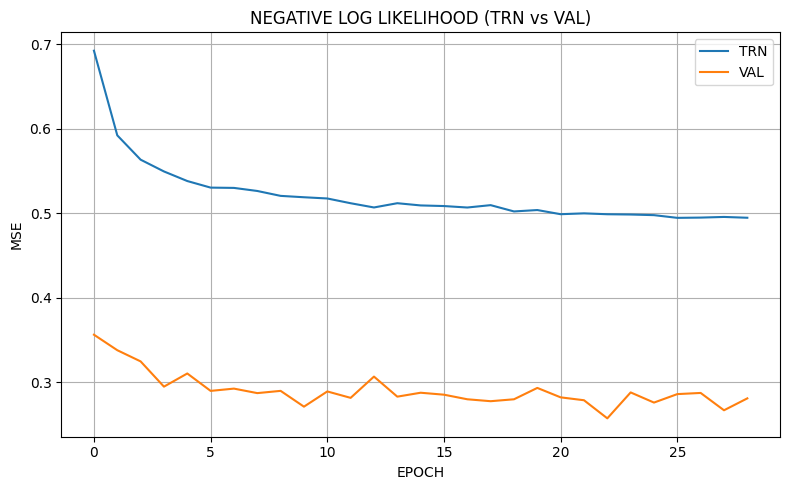

In [14]:
kwargs = dict(
    objs=(records["trn"]["nll"], records["val"]["nll"]),
    labels=("TRN", "VAL"),
    xlabel="EPOCH",
    ylabel="MSE",
    title="NEGATIVE LOG LIKELIHOOD (TRN vs VAL)",
    figsize=(8,5),
)

utils.visualizer.main(**kwargs)

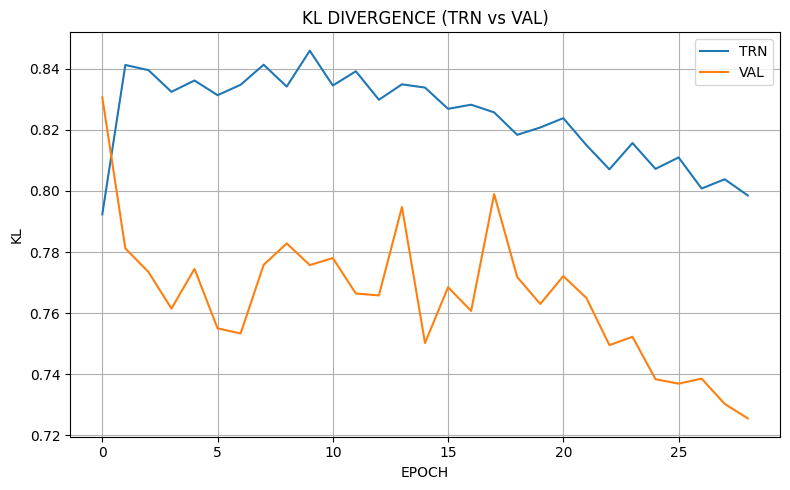

In [15]:
kwargs = dict(
    objs=(records["trn"]["kl"], records["val"]["kl"]),
    labels=("TRN", "VAL"),
    xlabel="EPOCH",
    ylabel="KL",
    title="KL DIVERGENCE (TRN vs VAL)",
    figsize=(8,5),
)

utils.visualizer.main(**kwargs)

# Evaluation

In [16]:
kwargs = dict(
    model=model,
    scores=records["anomaly"],
    cfg=cfg.evaluator,
)

eval = evaluator.builder.evaluator_builder(**kwargs)

In [17]:
result, metrics_sheet = eval(dataloaders["tst"])

TST: 100%|██████████| 8/8 [00:00<00:00, 358.92it/s]


In [18]:
metrics_sheet

,p,threshold,tp,tn,fp,fn,accuracy,precision,recall,f1
0,0.950,0.607693,432,475,17,60,0.921748,0.962138,0.878049,0.918172
1,0.955,0.652293,429,475,17,63,0.918699,0.961883,0.871951,0.914712
2,0.960,0.709498,428,478,14,64,0.920732,0.968326,0.869919,0.916488
3,0.965,0.787209,426,482,10,66,0.922764,0.977064,0.865854,0.918103
4,0.970,0.887513,416,482,10,76,0.912602,0.976526,0.845528,0.906318
5,0.975,1.033273,415,486,6,77,0.915650,0.985748,0.843496,0.909091
6,0.980,1.244479,411,486,6,81,0.911585,0.985611,0.835366,0.904290
7,0.985,1.549926,410,488,4,82,0.912602,0.990338,0.833333,0.905077
8,0.990,2.208783,398,489,3,94,0.901423,0.992519,0.808943,0.891377
9,0.995,3.412388,365,491,1,127,0.869919,0.997268,0.741870,0.850816


# Save

In [ ]:
PATH = f'./result/score/{cfg.model_cls}_{NOISE}.csv'

kwargs = dict(
    path_or_buf=PATH,
    index=False,
)
result.to_csv(**kwargs)

In [ ]:
PATH = f'./result/metric/{cfg.model_cls}_{NOISE}.csv'

kwargs = dict(
    path_or_buf=PATH,
    index=False,
)
metrics_sheet.to_csv(**kwargs)

In [20]:
PATH = f'./checkpoints/{cfg.model_cls}_{NOISE}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)